In [ ]:
from shot_processing import *
from lightfield_proceesing import * 
from pathlib import Path
import hashlib
import csv 
import re
import sys
import json
import ast
import numpy as np
import h5py
import spe2py as spe
import scipy.io
import matplotlib.pyplot as plt

ingested = load_manifest()
f = open_h5()

: 

In [13]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
from collections import Counter
import json
from pathlib import Path
from scipy.signal import find_peaks

OUT_H5 = Path("/Users/elyselian/Downloads/Python Code/S_XB/sxb_analysis/curated/experiment.h5")

# -------------------------------------------------------------------
# 1.  Helper: count monotonicity violations (approx-hollow detection)
def count_hollow_violations(I):
    dI = np.diff(I)
    signs = np.sign(dI)
    count = np.count_nonzero(signs > 0)
    return np.sum(count)

def count_monotonicity(I, incr=True):
    dI = np.diff(I)
    signs = np.sign(dI)
    if incr:
        count = np.count_nonzero(signs > 0)
    else:
        count = np.count_nonzero(signs < 0)
    return np.sum(count)

def check_slope(I):
    normalized_I = I / np.max(I)
    p = np.polyfit(np.arange(len(I)), normalized_I, 1)
    slope = p[0]  
    return slope

def count_oscillatory(I, high=True):
    normalized_I = I / np.max(I)
    dI = np.diff(normalized_I)
    if high:
        count = np.count_nonzero(np.abs(dI) > 0.1)
    else:
        count = np.count_nonzero(np.abs(dI) < 0.1)
    return np.sum(count)

def is_dome_profile(intensity, prominence=0.15, min_width=1, smooth_window=3,
                    baseline_fraction=0.4, edge_fraction=0.2, center_fraction=0.1):

    y = np.asarray(intensity, dtype=float)
    y = intensity / np.max(intensity)  # normalize 0–1

    # --- Smooth ---
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        y = np.convolve(y, kernel, mode="same")

    # --- Find the main peak ---
    peaks, props = find_peaks(y, prominence=prominence, width=min_width)
    if len(peaks) == 2:
        return "double peak dome"
    if len(peaks) != 1:
        return False

    p = peaks[0]
    peak_val = y[p]

    # --- Check slope shape (rise then fall) ---
    left_slope  = np.mean(np.diff(y[:p]))
    right_slope = np.mean(np.diff(y[p:]))
    if left_slope <= 0 or right_slope >= 0:
        return False

    # --- Check baseline outside the dome ---
    n = len(y)
    edge_n = max(1, int(edge_fraction * n))
    outside_indices = list(range(edge_n)) + list(range(n - edge_n, n))
    baseline_count = np.count_nonzero(y[outside_indices] >= baseline_fraction * peak_val)
    baseline = np.mean(y[outside_indices])

    if baseline >= baseline_fraction * peak_val:
        return False
    if baseline_count > 2:
        return False  # baseline too high, not a clear dome
    
    # --- Classify position ---
    center_region = (0.5 - center_fraction, 0.5 + center_fraction)
    peak_pos = p / (n - 1)  # normalized [0,1] position
    location = "center"
    if center_region[0] <= peak_pos <= center_region[1]:
        location = "center"
    elif peak_pos < center_region[0]:
        location = "off-center left"
    else:
        location = "off-center right"

    return location


def is_hollow_profile(intensity, prominence=0.1, min_width=2, smooth_window=3):

    y = np.asarray(intensity, dtype=float)
    y = (y - np.nanmin(y)) / (np.nanmax(y) - np.nanmin(y) + 1e-12)  # normalize 0–1

    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        y = np.convolve(y, kernel, mode="same")

    troughs, props = find_peaks(-y, prominence=prominence, width=min_width)

    # if len(troughs) == 2:
    #     return "double trough hollow"
    if len(troughs) != 1:
        return False 

    t = troughs[0]
    left_slope  = np.mean(np.diff(y[:t]))   # should be negative (downward)
    right_slope = np.mean(np.diff(y[t:]))   # should be positive (upward)

    if left_slope >= 0 or right_slope <= 0:
        return False

    # Optional: reject noisy profiles
    roughness = np.sum(np.abs(np.diff(y)))
    if roughness > 2.5:
        return False

    return True

def classify_profile(I, asym_thresh=0.2, max_violations=10, smooth=5):

    N = len(I) // 2
    left, right = I[:N], np.flip(I[N:])
    I_left_out, I_right_out = np.max(left), np.max(right)
    sym_ratio = abs(I_left_out - I_right_out) / max(I_left_out, I_right_out)

    violations = count_hollow_violations(left) + count_hollow_violations(right)
    slope_left = check_slope(left)
    slope_right = check_slope(right)

    num_incr = count_monotonicity(I, incr=True)
    num_decr = count_monotonicity(I, incr=False)
    num_oscillatory = count_oscillatory(I, high=True)
    num_flat = count_oscillatory(I, high=False)
    slope = check_slope(I)
    slope_thres = 0.5 * (1/20)
    normalized_I = I / np.max(I)
    is_dome = is_dome_profile(I, prominence=0.6, min_width=1, smooth_window=1) 
    is_hollow = is_hollow_profile(I, prominence=0.1, min_width=5, smooth_window=1)

    if is_hollow is True and violations < 7:
        return "hollow"
    else:
        return "non-hollow"

    # # 1. hollow symmetric
    # if sym_ratio < asym_thresh and violations < 5:
    #     return "hollow_symmetric"
    # # 2. hollow nonsymmetric
    # elif violations < 5:
    #     return "hollow_nonsymmetric"
    # elif num_oscillatory > 10:
    #     return "oscillatory"
    # elif is_hollow is True:
    #     return "off-center hollow"
    # elif is_hollow == "double trough hollow" or is_dome == "double peak dome":
    #     return "double peak"
    # elif is_dome == "center":
    #     return "centered dome"
    # elif is_dome == "off-center left":
    #     return "off-center left dome"
    # elif is_dome == "off-center right":
    #     return "off-center right dome"
    # elif num_incr > 8 and slope > slope_thres:
    #     return "increasing left to right"
    # elif num_decr > 8 and slope < -slope_thres:
    #     return "decreasing left to right"
    # elif num_flat > 15:
    #     return "flat"
    # else: 
    #     return "don't know what this is"

# # -------------------------------------------------------------------
# # Main loop: read, extract intensity array (20 peaks), classify, write metadata
# labels = []
# profiles = []
# shot_names = []

# with h5py.File(OUT_H5, "a") as f:
#     shots_grp = f["shots"]
#     for shot_key, grp in shots_grp.items():
#         dset = grp.get("image")
#         if dset is None:
#             continue

#         img = dset[()]
#         H, W = img.shape
#         col_idx = W // 2
#         col = img[:, col_idx].astype(float)

#         # smoothing (moving average)
#         smooth_window = 12
#         if smooth_window > 1:
#             kernel = np.ones(smooth_window) / smooth_window
#             col_smooth = np.convolve(col, kernel, mode="same")
#         else:
#             col_smooth = col

#         # peak detection parameters
#         min_distance = 35
#         multiplication = 0.6
#         height_thresh = col_smooth.mean() -  multiplication * col_smooth.std()
#         peaks, props = find_peaks(col_smooth, distance=min_distance, height=height_thresh)
#         iter = 0 

#         while len(peaks) != 20:
#             height_thresh = col_smooth.mean() -  multiplication * col_smooth.std()
#             peaks, props = find_peaks(col_smooth, distance=min_distance, height=height_thresh)
#             multiplication += 0.1
#             iter += 1
#             if iter > 20:
#                 break

#         if len(peaks) < 20:
#             # if fewer than 20 peaks found, skip classification
#             continue

#         # take top 20 peaks by height
#         peak_heights = props["peak_heights"]
#         top_idx = np.argsort(peak_heights)[-20:]
#         intensities = peak_heights[top_idx]
#         intensities = intensities[np.argsort(top_idx)]  # reorder spatially
#         profiles.append(intensities)
#         shot_names.append(shot_key)

#         label = classify_profile(intensities)
#         labels.append(label)

#         # write classification and peak data as metadata
#         for obj in (grp, dset):
#             obj.attrs["profile_shape"] = label
#             obj.attrs["peak_heights"] = intensities.astype(np.float32)

# print(f"Processed {len(shot_names)} shots with valid 20-peak profiles.")

# # -------------------------------------------------------------------
# # Summarize classification counts
# totals = Counter(labels)
# print("\nClassification counts:")
# for k, v in totals.items():
#     print(f"  {k:<24s}: {v}")

# -------------------------------------------------------------------
# Main loop: read photon_flux (20 values), classify, write metadata
labels = []
profiles = []
shot_names = []

with h5py.File(OUT_H5, "a") as f:
    shots_grp = f["shots"]
    for shot_key, grp in shots_grp.items():
        dset = grp.get("image")
        if dset is None:
            continue

        # Retrieve photon_flux array from metadata (group preferred, fallback to dataset)
        pf = grp.attrs.get("photon_flux")
        if pf is None and dset is not None:
            pf = dset.attrs.get("photon_flux")
        if pf is None:
            continue  # skip shots without photon_flux

        intensities = np.asarray(pf, dtype=float).ravel()
        if intensities.size != 20:
            continue  # enforce expected size

        profiles.append(intensities)
        shot_names.append(shot_key)

        label = classify_profile(intensities)
        labels.append(label)

        # Write classification (keep original photon_flux attribute; also store a copy as peak_heights if needed)
        for obj in (grp, dset):
            obj.attrs["profile_shape"] = label
            obj.attrs["peak_heights"] = intensities.astype(np.float32)  # reuse field for downstream code expecting it

print(f"Processed {len(shot_names)} shots with valid 20-value photon_flux profiles.")

# -------------------------------------------------------------------
# Summarize classification counts
totals = Counter(labels)
print("\nClassification counts:")
for k, v in totals.items():
    print(f"  {k:<24s}: {v}")

Processed 434 shots with valid 20-value photon_flux profiles.

Classification counts:
  non-hollow              : 337
  hollow                  : 97


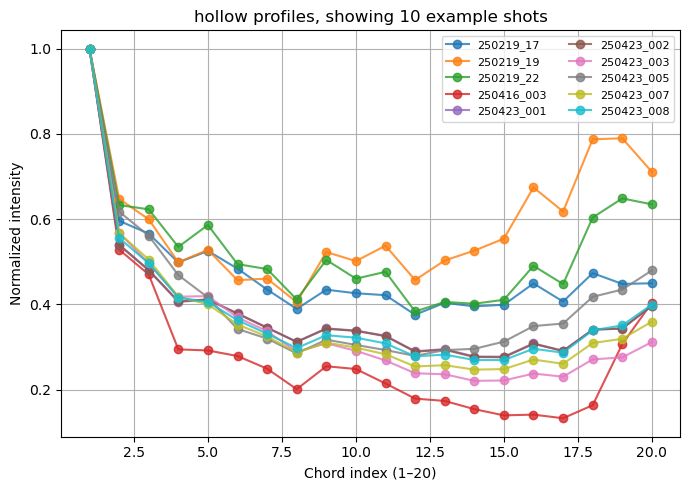

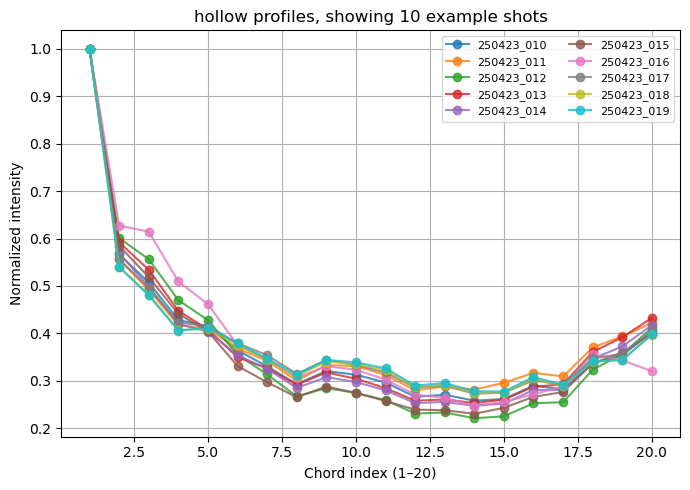

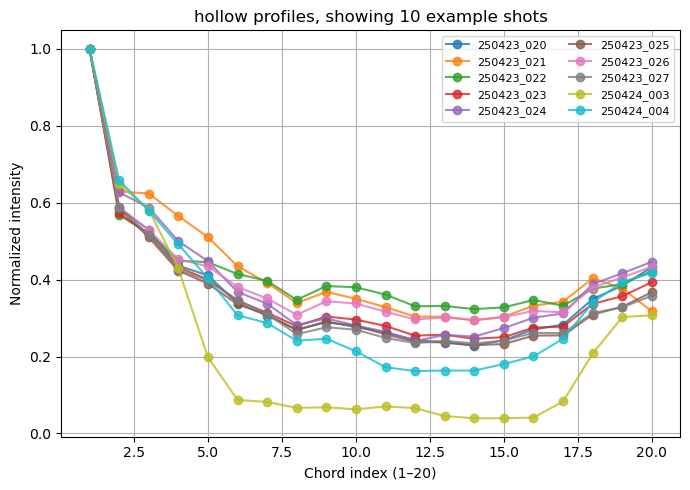

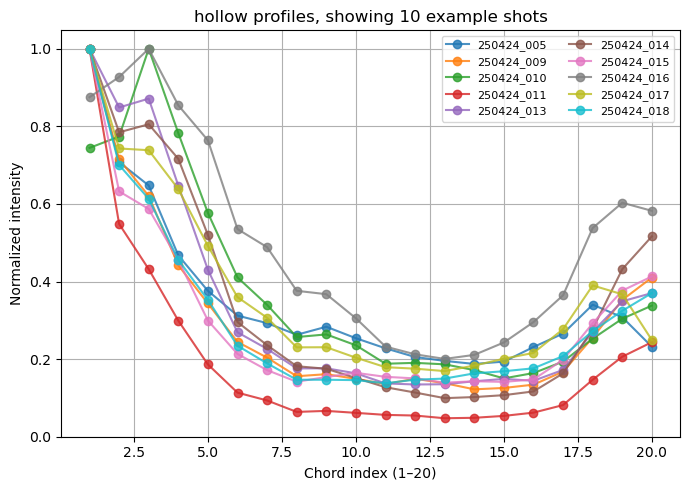

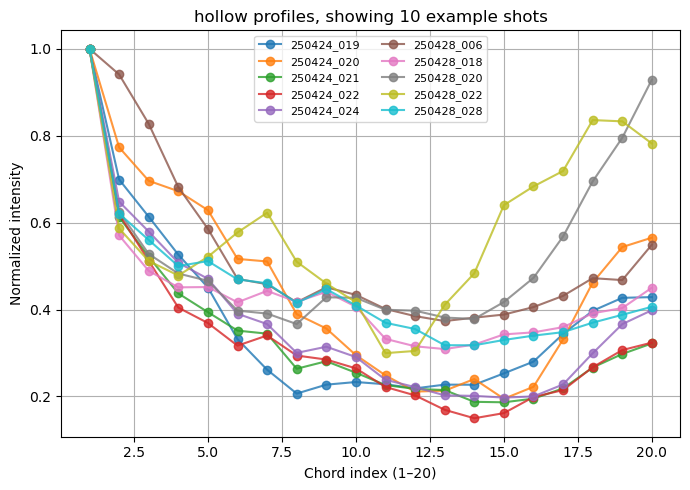

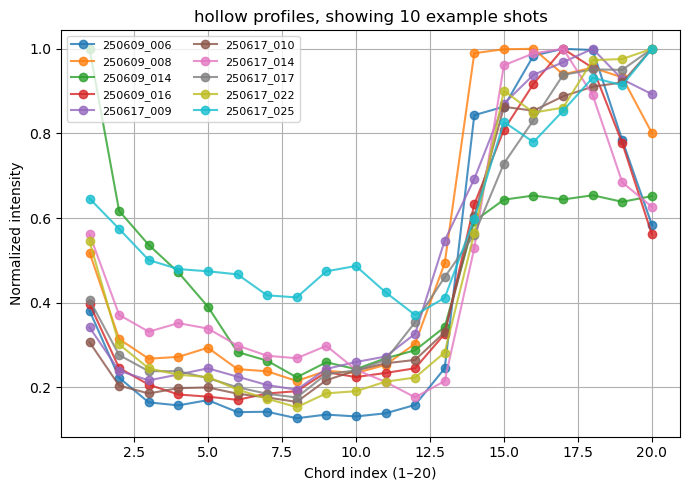

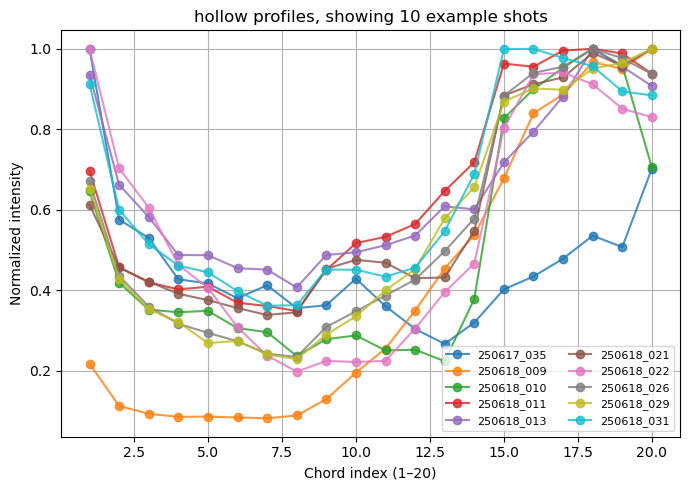

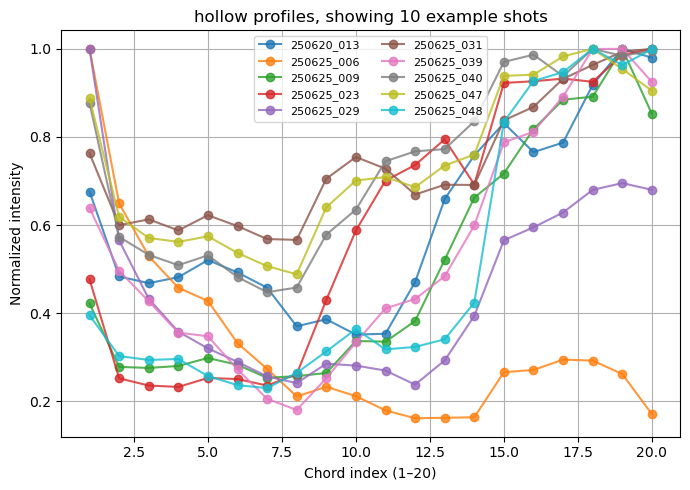

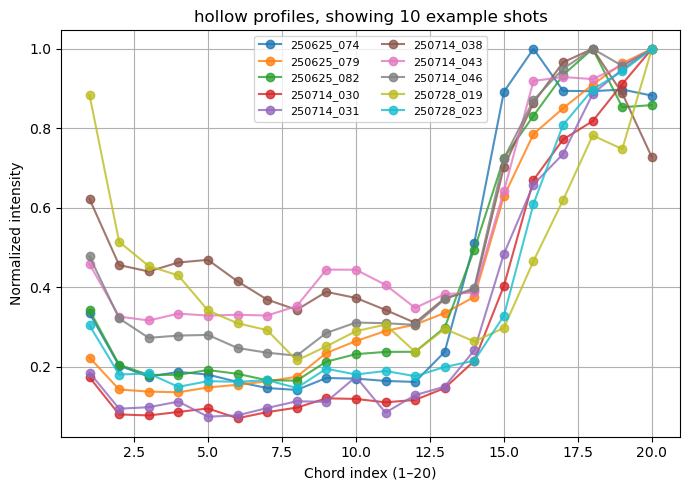

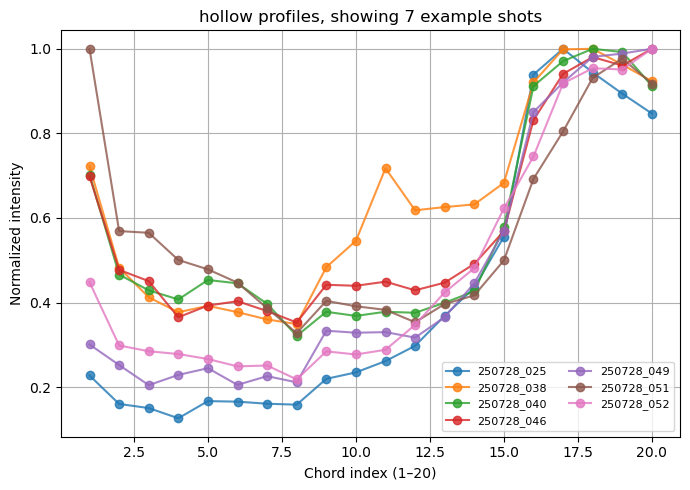

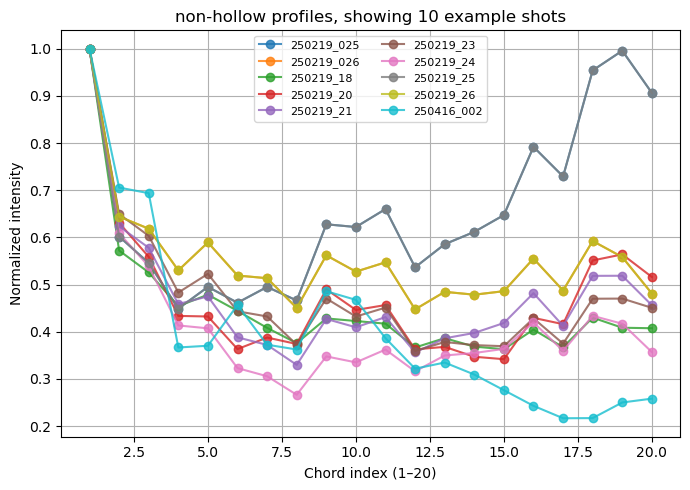

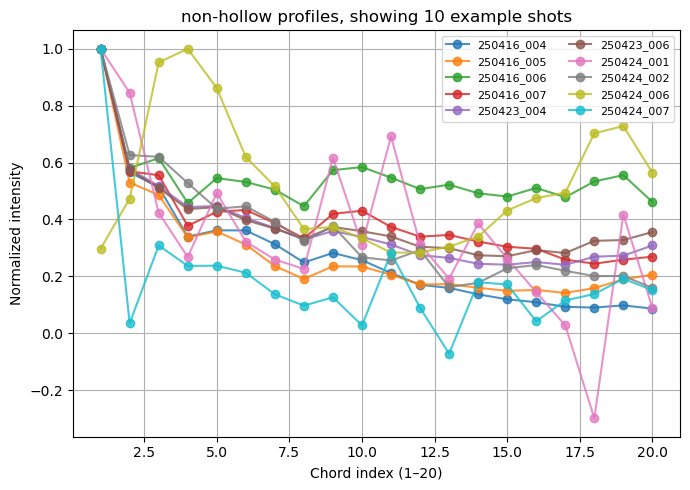

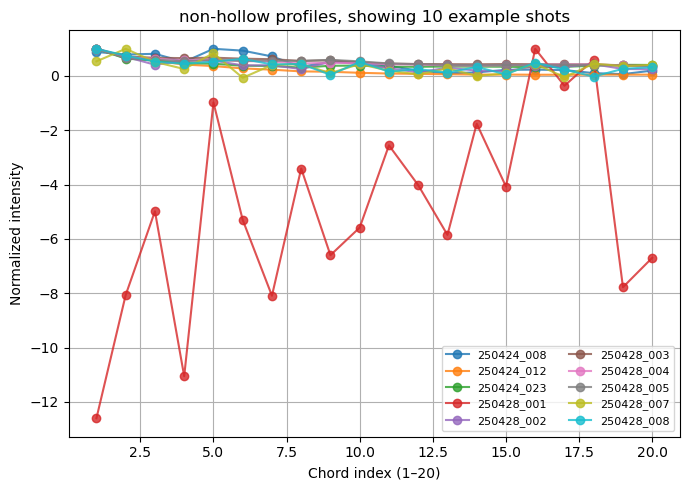

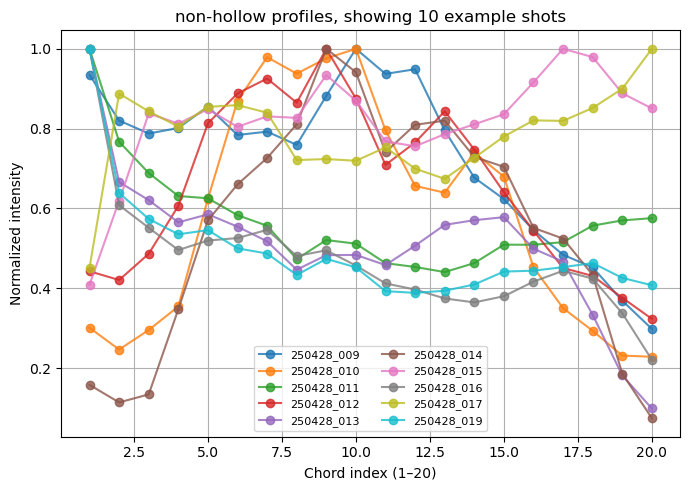

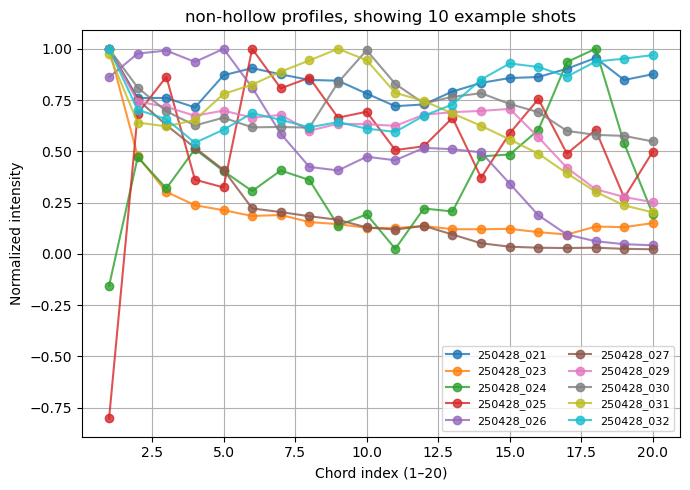

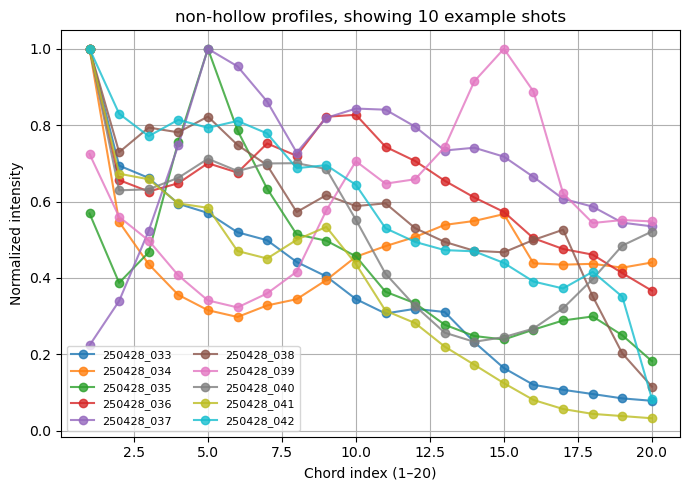

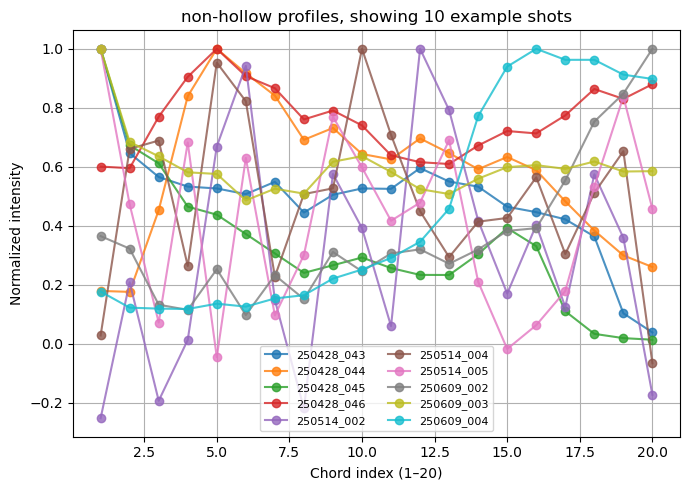

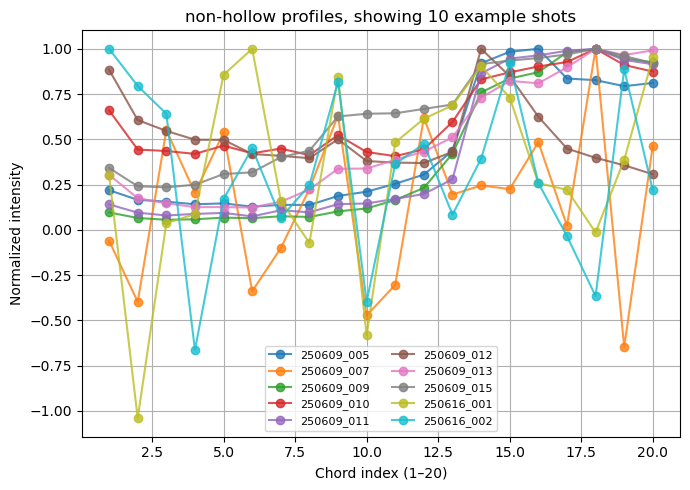

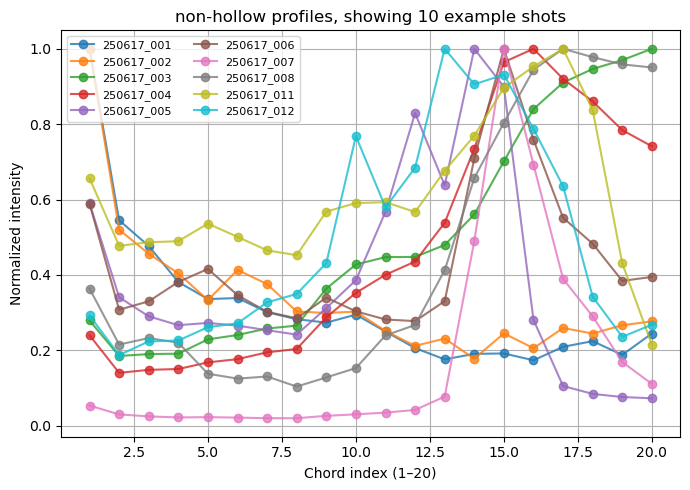

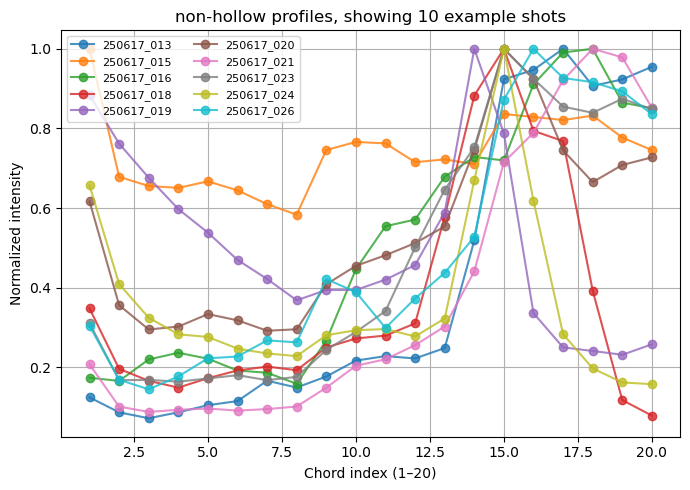

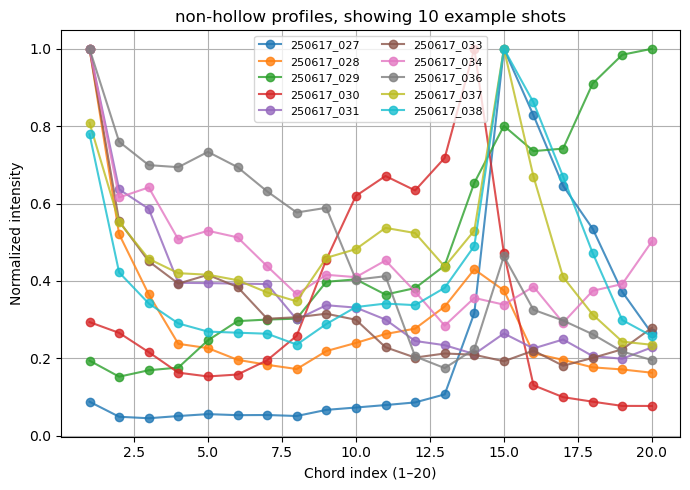

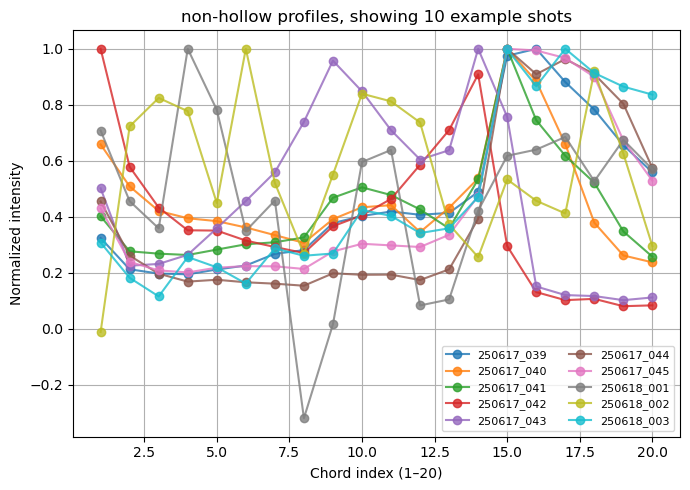

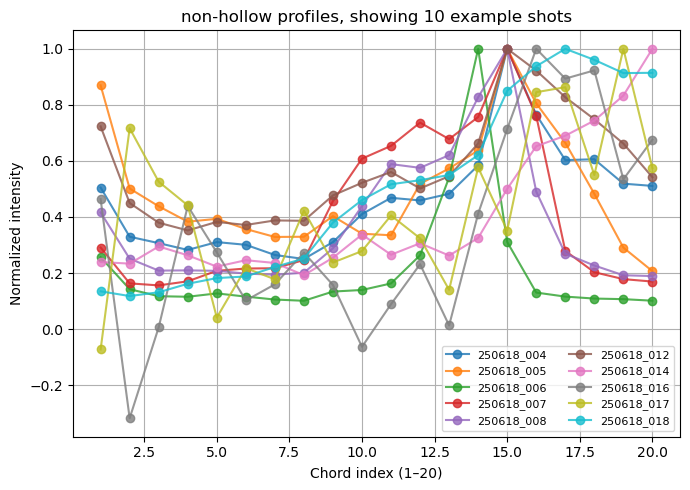

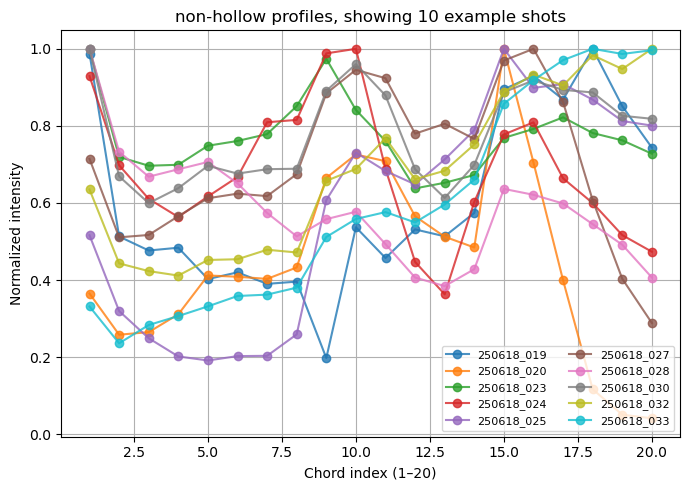

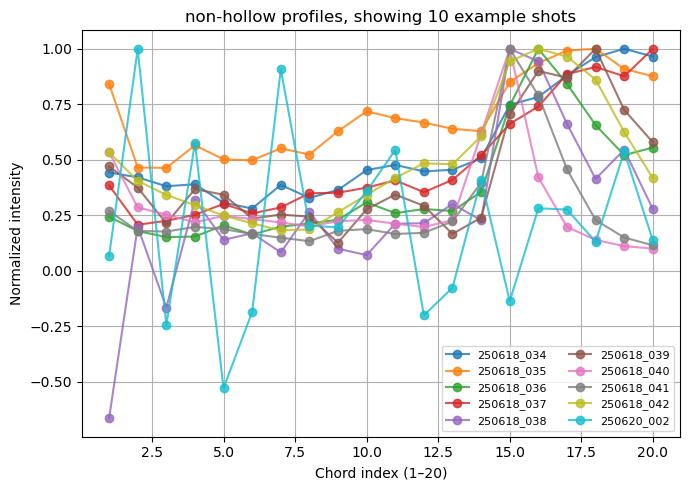

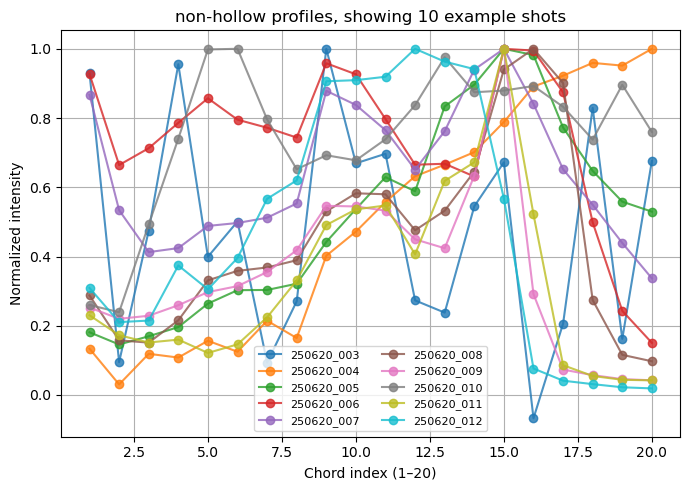

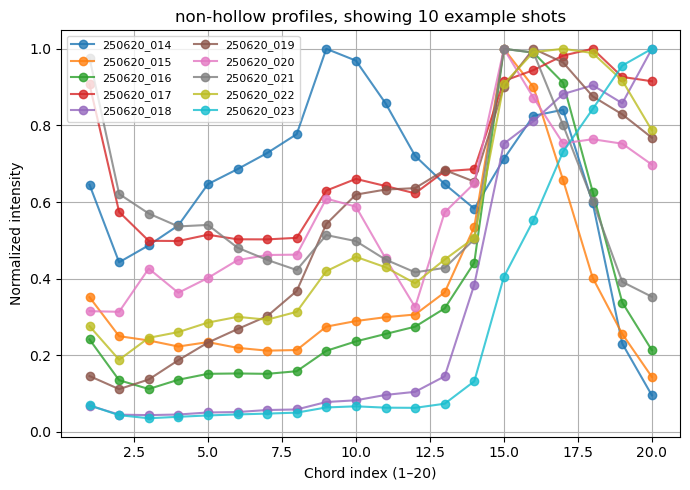

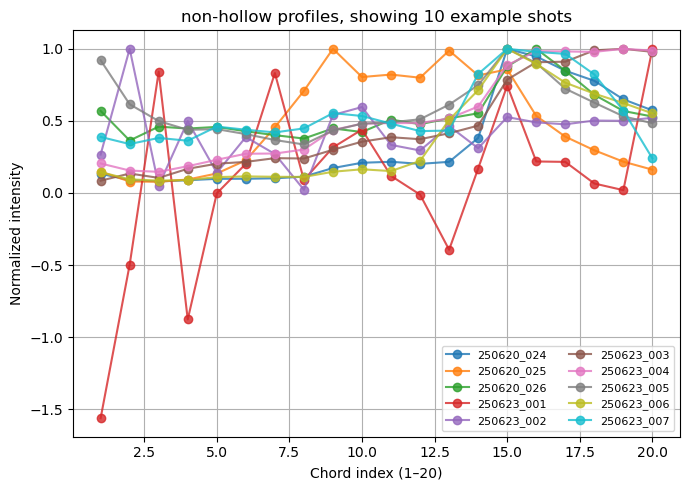

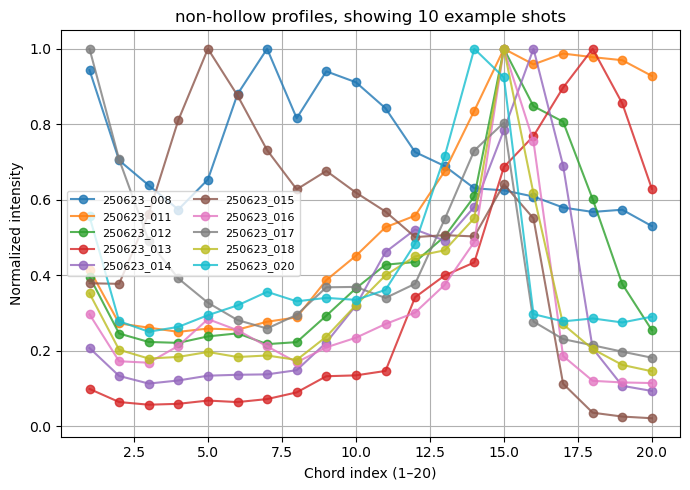

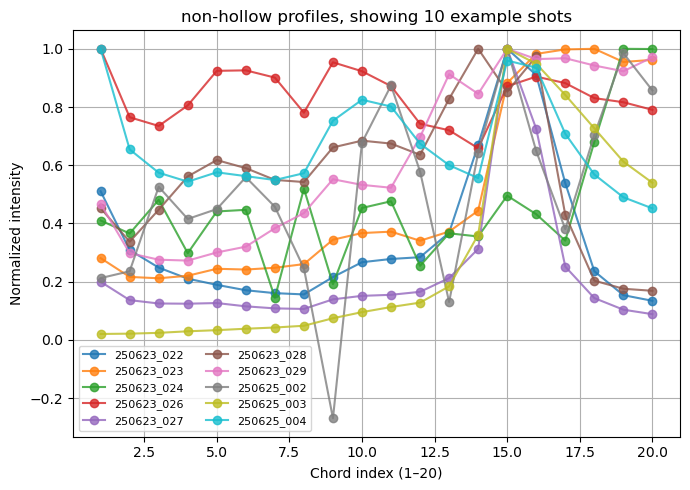

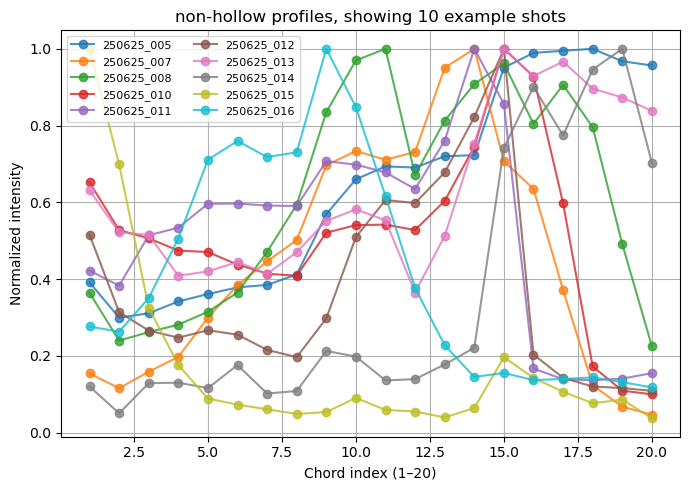

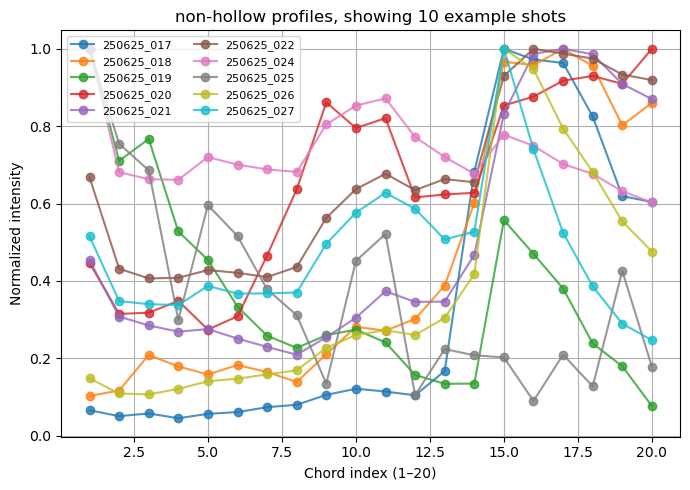

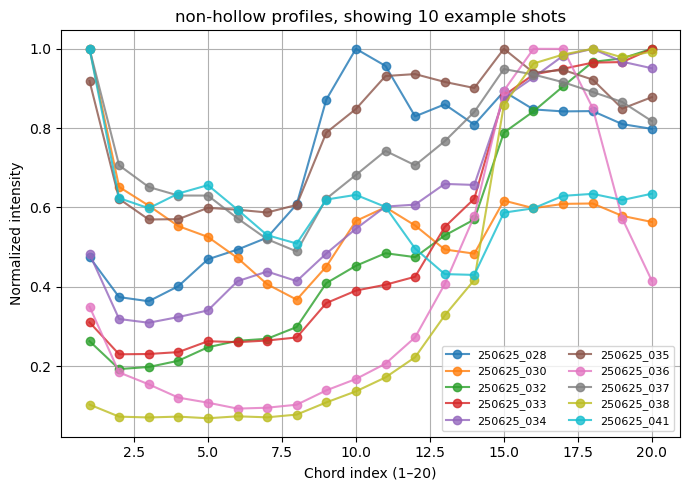

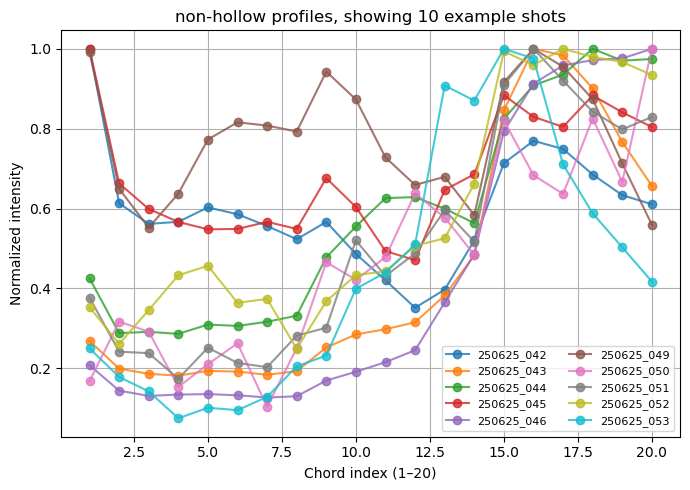

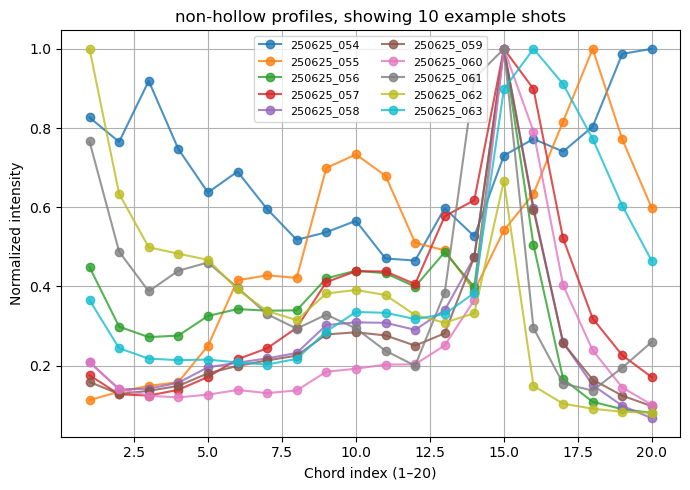

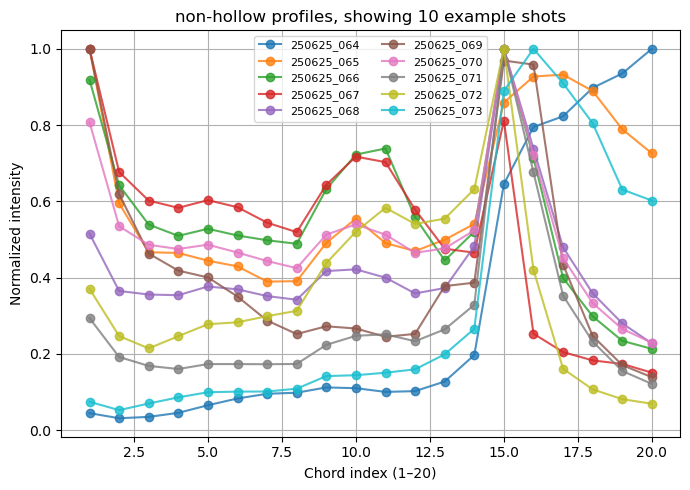

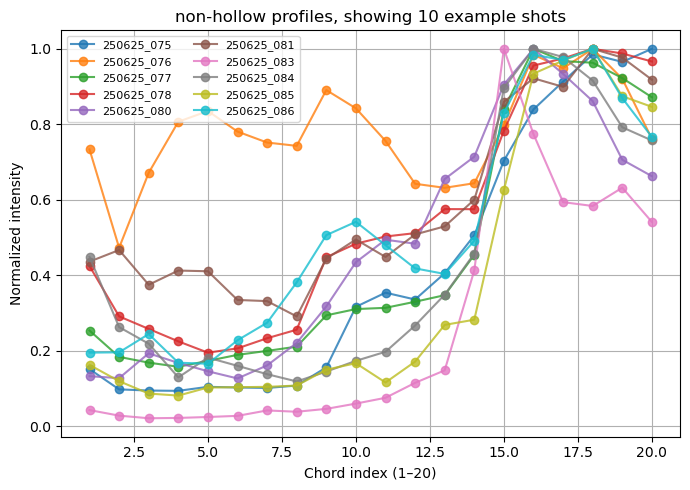

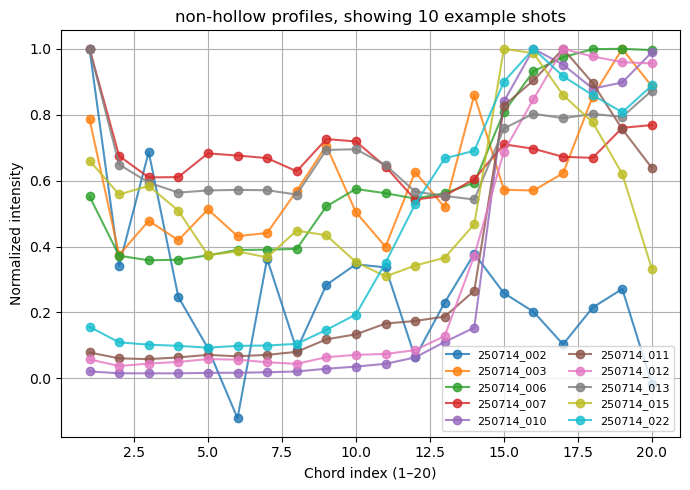

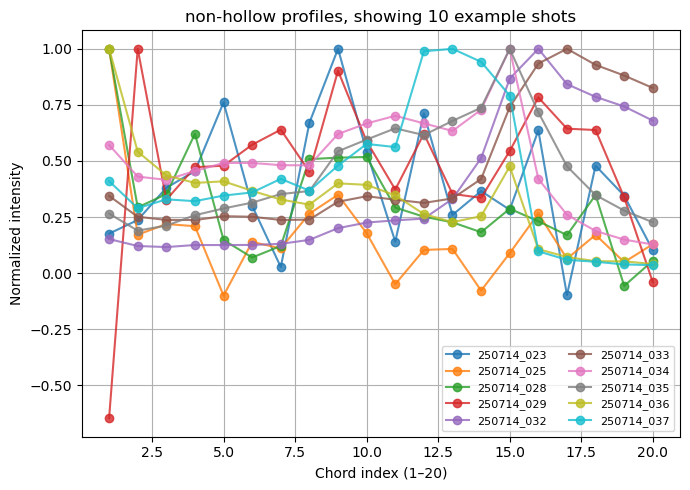

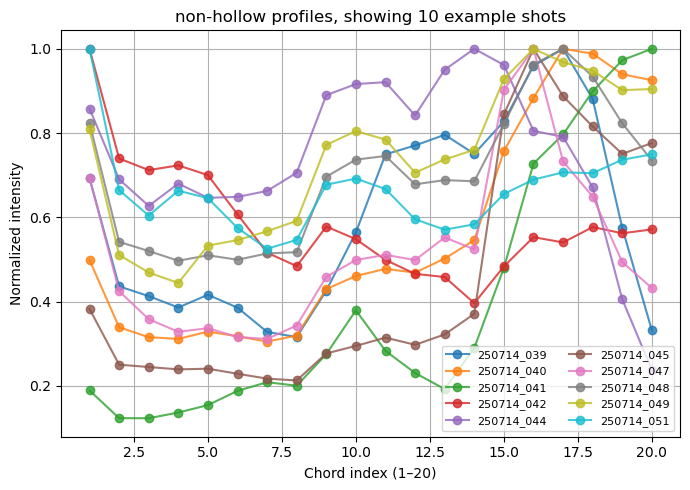

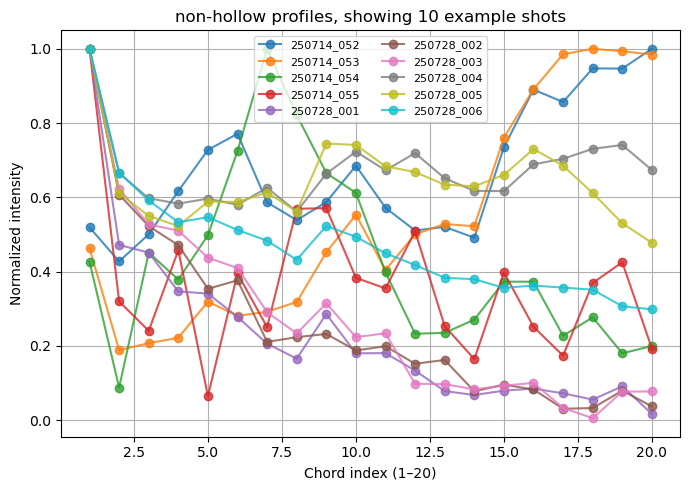

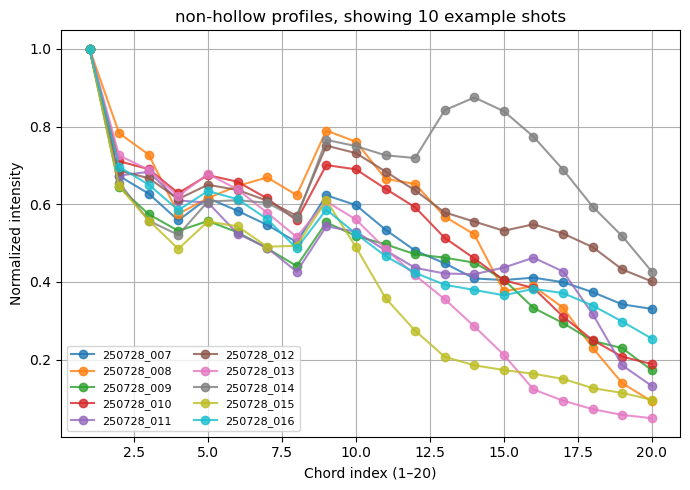

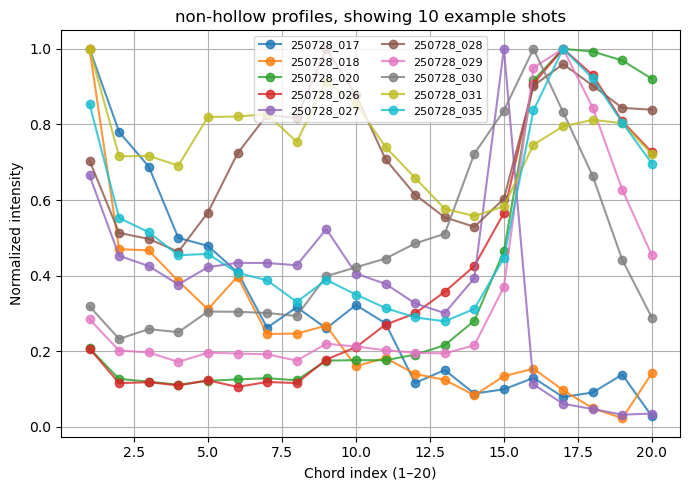

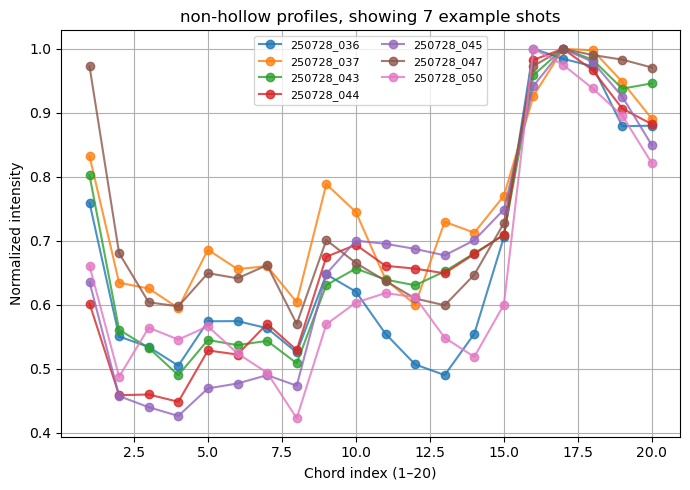

In [20]:
# ...existing code...
def plot_examples(labels, profiles, shot_names, class_name, n=None, per_fig=10, date_filter=None):
    """
    Plot examples of a specific class, optionally filtered by date.

    - n: total shots to show (None = all)
    - per_fig: max curves per figure (new plot when exceeded)
    """
    # Filter by class
    class_idxs = [i for i, lbl in enumerate(labels) if lbl == class_name]

    # Optional date filter
    if date_filter:
        class_idxs = [i for i in class_idxs if shot_names[i].startswith(date_filter)]

    # Limit total if requested
    idxs = class_idxs if n is None else class_idxs[:n]
    if not idxs:
        suffix = f" (date: {date_filter})" if date_filter else ""
        print(f"No profiles found for {class_name}{suffix}")
        return

    title_suffix = f" (date: {date_filter})" if date_filter else ""

    # Chunk into pages of per_fig shots
    total_pages = (len(idxs) - 1) // per_fig + 1
    for start in range(0, len(idxs), per_fig):
        batch = idxs[start:start + per_fig]

        plt.figure(figsize=(7, 5))
        for i in batch:
            I = profiles[i] / np.max(profiles[i])
            shot_label = shot_names[i]
            plt.plot(np.arange(1, len(I) + 1), I, "o-", alpha=0.8, label=f"{shot_label}")

        page = start // per_fig + 1
        plt.title(f"{class_name} profiles, showing {len(batch)} example shots{title_suffix}")
        plt.xlabel("Chord index (1–20)")
        plt.ylabel("Normalized intensity")
        # plt.ylim([0, 1.1])
        plt.grid(True)
        plt.legend(fontsize=8, loc="best", ncol=2)
        plt.tight_layout()
        plt.show()

# -------------------------------------------------------------------
# Plot all classes (no date filter)
# for cname in [
#     "hollow_symmetric", "hollow_nonsymmetric", "off-center hollow",
#     "increasing left to right", "decreasing left to right",
#     "oscillatory", "flat", "centered dome", "off-center left dome", "off-center right dome",
#     "don't know what this is"
# ]:

for cname in ["hollow", "non-hollow"]:
    # plot_examples(labels, profiles, shot_names, cname, date_filter="250609")
    plot_examples(labels, profiles, shot_names, cname)

# Example: Plot only shots from specific dates
# Uncomment and modify these lines to filter by date:
# plot_examples(labels, profiles, shot_names, "hollow_nonsymmetric", n=5, date_filter="250219")
# plot_examples(labels, profiles, shot_names, "hollow_symmetric", n=5, date_filter="250424")